# 01 · GPU Digital Fingerprinting & Threat Classification

            A reproducible comparison of supervised and benign-only anomaly detection for synthetic GPU workload behavior.

## tl;dr

            Across **239 held-out challenge events**, the bounded Random Forest reaches **82.1% F1** with **76.5% recall**. The benign-only Isolation Forest reaches **68.2% F1**. The supervised model catches more known patterns; the anomaly model needs no attack labels but misses more evasive cases.

## Context & Methods

            We model GPU telemetry as a digital fingerprint: utilization, memory pressure, power, egress, image trust, privilege, host access, and model access. The train/test assignment deliberately holds out some lower-signal attack variants.

            ### Key Assumptions

            - Every row and attack label is synthetic; metrics validate code paths, not production performance.
            - Attestation is excluded from the behavior classifier so hardware trust cannot leak the label.
            - A high anomaly score prioritizes review; it does not prove compromise.

## Data

Load the versioned corpus and validate its population, split, and label coverage.

In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
if not (ROOT / "pyproject.toml").exists():
    raise RuntimeError("Run this notebook from the repository or a child directory")
sys.path.insert(0, str(ROOT / "src"))

NVIDIA = "#76B900"
ORANGE = "#f97316"
BLUE = "#2563eb"
GOLD = "#d9a404"
PINK = "#db2777"
INK = "#172033"
GRID = "#e5e7eb"
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": INK,
    "axes.labelcolor": INK,
    "axes.titlecolor": INK,
    "text.color": INK,
    "xtick.color": INK,
    "ytick.color": INK,
    "font.size": 11,
    "axes.titlepad": 30,
})

In [2]:
from gpu_trust_guardian.features import FEATURE_COLUMNS, engineer_features

raw = pd.read_csv(ROOT / "data" / "synthetic_gpu_events.csv")
frame = engineer_features(raw)
population = pd.DataFrame({
    "rows": [len(frame)],
    "train": [(frame["split"] == "train").sum()],
    "test": [(frame["split"] == "test").sum()],
    "attack_rows": [frame["is_attack"].sum()],
    "scenarios": [frame["scenario"].nunique()],
})
population

,rows,train,test,attack_rows,scenarios
0,1320,1081,239,186,6


In [3]:
assert frame["event_id"].is_unique
assert set(frame["split"]) == {"train", "test"}
assert frame[FEATURE_COLUMNS].isna().sum().sum() == 0
assert set(frame["scenario"]) == {
    "trusted_training", "benign_inference", "cryptomining",
    "model_exfiltration", "container_escape", "untrusted_gpu",
}
print("Validated", len(frame), "synthetic events with", len(FEATURE_COLUMNS), "behavior features.")

Validated 1320 synthetic events with 10 behavior features.


## Results

Fit both models on the same training population and evaluate once on the challenge split.

In [4]:
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.metrics import confusion_matrix, f1_score, precision_score, recall_score, roc_auc_score

train = frame[frame["split"] == "train"].copy()
test = frame[frame["split"] == "test"].copy()

classifier = RandomForestClassifier(
    n_estimators=280, max_depth=6, min_samples_leaf=8,
    class_weight="balanced", random_state=42, n_jobs=1,
)
classifier.fit(train[FEATURE_COLUMNS], train["is_attack"])
rf_probability = classifier.predict_proba(test[FEATURE_COLUMNS])[:, 1]
rf_prediction = (rf_probability >= 0.5).astype(int)

detector = IsolationForest(n_estimators=260, contamination=0.10, random_state=42, n_jobs=1)
benign_train = train[train["is_attack"] == 0]
detector.fit(benign_train[FEATURE_COLUMNS])
if_threshold = np.quantile(-detector.score_samples(benign_train[FEATURE_COLUMNS]), 0.95)
if_score = -detector.score_samples(test[FEATURE_COLUMNS])
if_prediction = (if_score >= if_threshold).astype(int)

metric_rows = []
for model_name, prediction in [("Random Forest", rf_prediction), ("Isolation Forest", if_prediction)]:
    metric_rows.append({
        "model": model_name,
        "precision": precision_score(test["is_attack"], prediction, zero_division=0),
        "recall": recall_score(test["is_attack"], prediction, zero_division=0),
        "f1": f1_score(test["is_attack"], prediction, zero_division=0),
    })
metrics = pd.DataFrame(metric_rows)
metrics

,model,precision,recall,f1
0,Random Forest,0.886364,0.764706,0.821053
1,Isolation Forest,0.810811,0.588235,0.681818


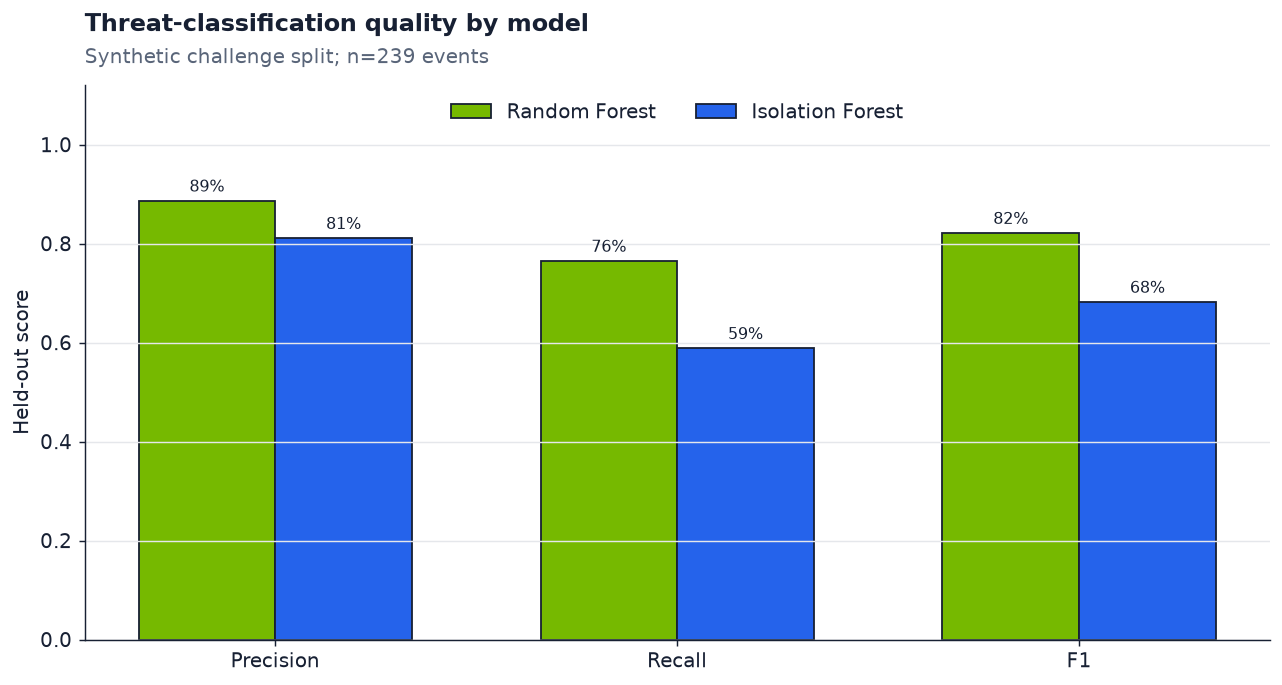

In [5]:
long_metrics = metrics.melt(id_vars="model", var_name="metric", value_name="score")
fig, ax = plt.subplots(figsize=(10, 5.4))
x = np.arange(3)
width = 0.34
for index, (model_name, color) in enumerate([("Random Forest", NVIDIA), ("Isolation Forest", BLUE)]):
    values = long_metrics[long_metrics["model"] == model_name].set_index("metric").loc[["precision", "recall", "f1"], "score"]
    bars = ax.bar(x + (index - .5) * width, values, width, label=model_name, color=color, edgecolor=INK)
    ax.bar_label(bars, labels=[f"{value:.0%}" for value in values], padding=3, fontsize=9)
ax.set_xticks(x, ["Precision", "Recall", "F1"])
ax.set_ylim(0, 1.12)
ax.set_ylabel("Held-out score")
ax.set_title("Threat-classification quality by model", loc="left", fontweight="bold")
ax.text(0, 1.04, f"Synthetic challenge split; n={len(test):,} events", transform=ax.transAxes, color="#596579")
ax.grid(axis="y", color=GRID, linewidth=.8)
ax.legend(frameon=False, ncol=2, loc="upper center")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

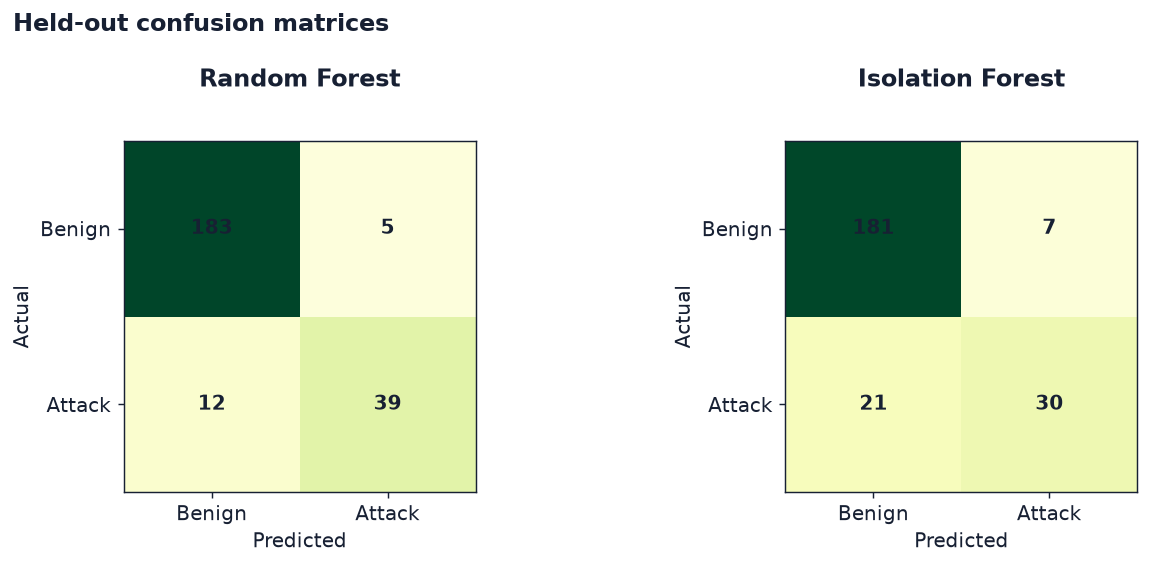

In [6]:
matrices = [
    ("Random Forest", confusion_matrix(test["is_attack"], rf_prediction)),
    ("Isolation Forest", confusion_matrix(test["is_attack"], if_prediction)),
]
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.4))
for ax, (title, matrix) in zip(axes, matrices):
    image = ax.imshow(matrix, cmap="YlGn", vmin=0, vmax=max(item.max() for _, item in matrices))
    for row in range(2):
        for column in range(2):
            ax.text(column, row, int(matrix[row, column]), ha="center", va="center", fontweight="bold")
    ax.set_title(title, fontweight="bold")
    ax.set_xticks([0, 1], ["Benign", "Attack"])
    ax.set_yticks([0, 1], ["Benign", "Attack"])
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
fig.suptitle("Held-out confusion matrices", x=.08, ha="left", fontweight="bold")
plt.tight_layout()
plt.show()

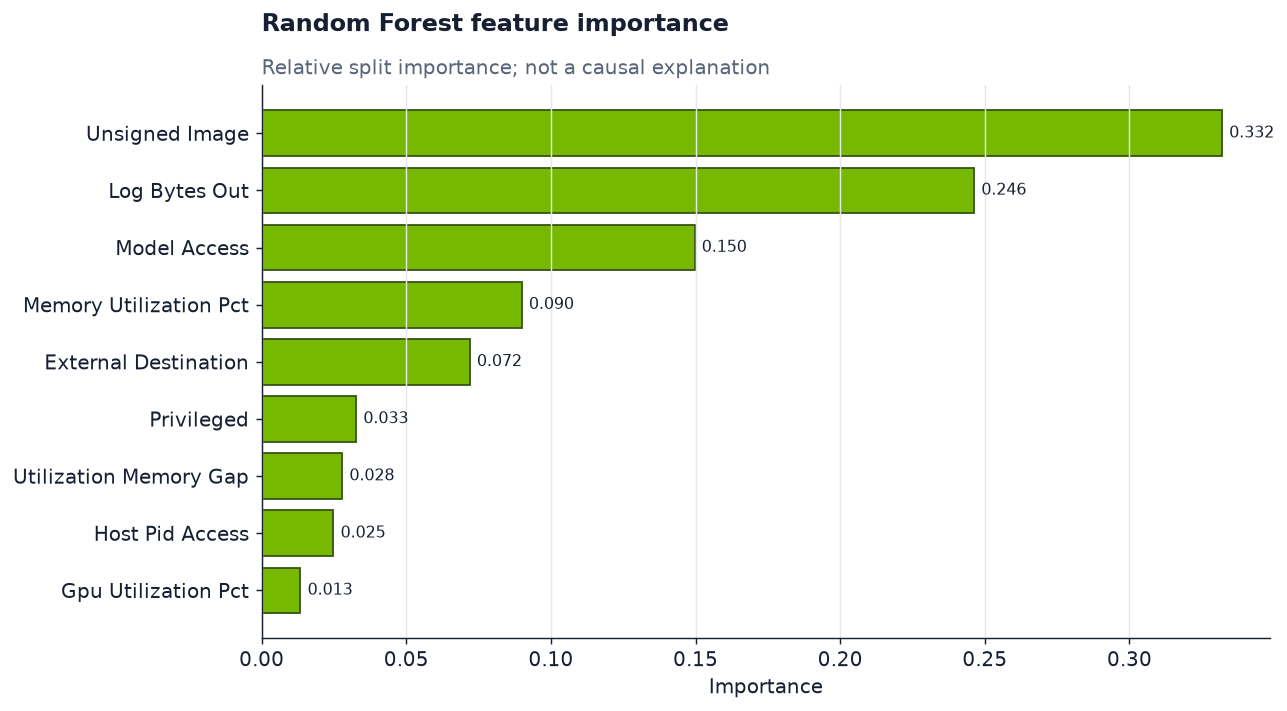

In [7]:
importance = pd.DataFrame({"feature": FEATURE_COLUMNS, "importance": classifier.feature_importances_}).sort_values("importance").tail(9)
fig, ax = plt.subplots(figsize=(10, 5.6))
bars = ax.barh(importance["feature"].str.replace("_", " ").str.title(), importance["importance"], color=NVIDIA, edgecolor="#365314")
ax.bar_label(bars, labels=[f"{value:.3f}" for value in importance["importance"]], padding=4, fontsize=9)
ax.set_title("Random Forest feature importance", loc="left", fontweight="bold")
ax.text(0, 1.02, "Relative split importance; not a causal explanation", transform=ax.transAxes, color="#596579")
ax.set_xlabel("Importance")
ax.grid(axis="x", color=GRID, linewidth=.8)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

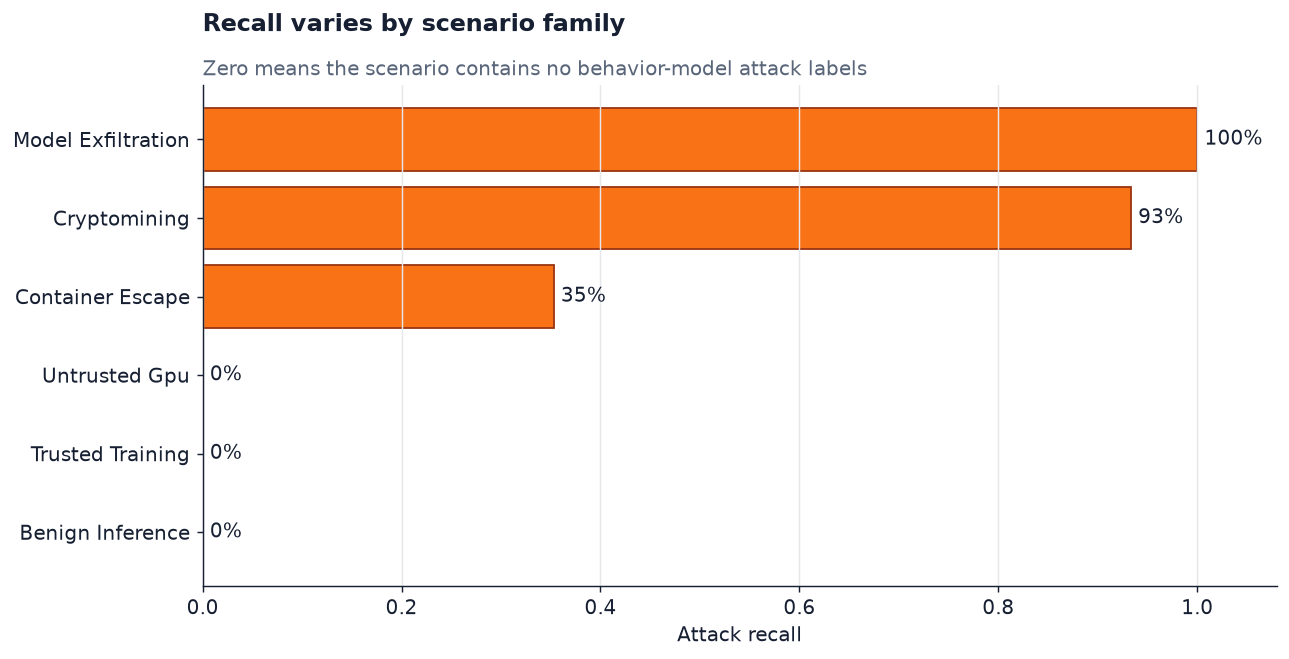

In [8]:
test_results = test[["scenario", "is_attack"]].copy()
test_results["rf_prediction"] = rf_prediction
scenario_quality = test_results.groupby("scenario").apply(
    lambda group: pd.Series({
        "events": len(group),
        "attack_recall": recall_score(group["is_attack"], group["rf_prediction"], zero_division=0),
    }), include_groups=False,
).reset_index().sort_values("attack_recall")

fig, ax = plt.subplots(figsize=(10, 5.2))
bars = ax.barh(scenario_quality["scenario"].str.replace("_", " ").str.title(), scenario_quality["attack_recall"], color=ORANGE, edgecolor="#9a3412")
ax.bar_label(bars, labels=[f"{value:.0%}" for value in scenario_quality["attack_recall"]], padding=4)
ax.set_xlim(0, 1.08)
ax.set_xlabel("Attack recall")
ax.set_title("Recall varies by scenario family", loc="left", fontweight="bold")
ax.text(0, 1.02, "Zero means the scenario contains no behavior-model attack labels", transform=ax.transAxes, color="#596579")
ax.grid(axis="x", color=GRID, linewidth=.8)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## Takeaways

            1. **Known patterns benefit from labels.** The Random Forest reaches **82.1% F1**, ahead of the benign-only detector at **68.2%**.
            2. **Recall is the main gap.** The supervised model misses **12 of 51** held-out attacks, including intentionally evasive variants.
            3. **Hardware trust stays separate.** Attestation is a deterministic policy input, not a shortcut feature for behavior classification.
            4. **Production next step:** validate on real, governed GPU telemetry with workload-aware splits and drift monitoring.